In [ ]:
# !pip install sep
#!pip install numba
#!pip install pypppc4dm
## The professor said that he wants something more than 
## just me plotting, so I guess 
## I'll try to create a simulation.

# AST 390 Final Assignment:

## Title: Dark Matter Annihilation Simulation and Uncertainty Analysis 
~~Theoretical and Computational Analysis of Dark Matter Annihilation in the Galactic Center~~ ~~This Title May Change~~

### Abstract:
This paper presents a computational simulation and analysis of dark-matter annihilation using four standard density profiles: Navarro-Frenk-White (NFW), Einasto, Moore, and Zhao. The simulation incorporates Monte Carlo methods to estimate uncertainties in the density profiles, computes annihilation rates as a function of radius, integrates total annihilation rates, and visualizes the results via plots and animations. The methodology provides insights into the spatial distribution of dark matter and the sensitivity of annihilation signals to model assumptions.

### Introduction:
Dark matter is believed to comprise about 27$\%$ of the universe’s mass-energy content and plays a central role in shaping the structure and evolution of the cosmos. Nevertheless, its nature remains one of modern astrophysics’ most significant open questions. While direct detection experiments have yet to yield definitive results, indirect detection methods—searching for the byproducts of dark matter interactions—offer a complementary strategy.

One such method focuses on dark matter annihilation, a process where two dark matter particles annihilate to produce standard-model particles such as gamma rays or neutrinos. The strength and distribution of the resulting signal depend sensitively on the spatial distribution of dark matter, particularly in high-density regions like galactic centers. Accurately modeling the dark matter density profile is essential for interpreting potential annihilation signatures.

This project uses computational techniques to simulate and compare several commonly used dark matter halo profiles, including the Navarro-Frenk-White (NFW), Einasto, Moore, and Zhao models. These profiles differ in behavior near the halo center and at large radii, leading to substantial differences in the predicted annihilation rates. We implement Monte Carlo methods to estimate these rates for each profile and quantify how model choice influences the expected signals.

This work combines numerical modeling, statistical sampling, and astrophysical theory to support ongoing efforts in dark matter detection. The results will help clarify the implications of profile selection in indirect detection studies and enhance our ability to interpret future observational data.

### Objective:
The main objective of this study is to simulate and analyze the effects of dark matter annihilation in galactic centers using computational methods. This includes:

1. Modeling dark matter density profiles such as the Navarro-Frenk-White (NFW), Einasto, Moore, and Zhao profiles to compare their impact on annihilation predictions.



### Purpose and Future Work:
This study aims to provide a computational framework for understanding how dark matter annihilation in galactic centers could manifest in astrophysical observations. The purpose of this simulation is to:

1. Explore theoretical trends in annihilation rates and expected signals across different dark matter models.
2. Provide a simplified approach to studying indirect dark matter detection without requiring complex data analysis.
3. Utilizing precomputed spectra for annihilation channels to assess potential gamma-ray and neutrino emissions qualitatively.
4. Comparing theoretical predictions with observational constraints from telescopes like Fermi-LAT and IceCube. *May be subject to change if I cannot locate the document(s)*
5. Estimating the relative annihilation rate by exploring how different dark matter parameters (mass, cross-section, density profile) affect signal strength. (Unfortunately, I could not figure this out during the semester. I plan on working on this after the semester is over.)
___________________

#### Imports:

In [1]:
## ᕦ(ò_óˇ)ᕤ I cannot do anything without having the imports!

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from scipy.stats import norm
from scipy.integrate import quad
from scipy.integrate import solve_ivp
from tqdm import tqdm  # For the loading bar
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
from numba import njit

#from pypppc4dm import PPPC4DM

## (～￣▽￣)～ I am not sure if I really need all of these imports.
##            BUT! I'll keep them.

In [3]:
## (ﾉ◕ヮ◕)ﾉ*:･ﾟ✧ Making my life hard for choosing a weird subject!

# Define constants
rho_s = 0.3  # Scale density (M⨀/kpc³)
r_s = 20.0   # Scale radius in kpc
sigma_v = 3e-26  # Annihilation cross-section (cm^3/s)
m_chi = 100  # Dark matter particle mass (GeV)

@njit()
# Define dark matter density profiles
def nfw_profile(r, rho_s, r_s):
    """Navarro-Frenk-White dark matter density profile."""
    return rho_s / ((r / r_s) * (1 + r / r_s)**2)

def einasto_profile(r, rho_s, r_s, alpha=0.17):
    """Einasto dark matter density profile."""
    return rho_s * np.exp(- (2 / alpha) * ((r / r_s)**alpha - 1))

def moore_profile(r, rho_s, r_s):
    return rho_s / ((r / r_s)**1.5 * (1 + (r / r_s)**1.5))

def zhao_profile(r, rho_s, r_s, gamma=1.0, alpha=1.0, beta=3.0):
    return rho_s / ((r / r_s)**gamma * (1 + (r / r_s)**alpha)**((beta - gamma) / alpha))

In [5]:
# Monte Carlo uncertainty calculation
def monte_carlo_uncertainty(profile_func, r, rho_s, r_s, num_samples=100000):
    samples = [profile_func(r, rho_s * (1 + 0.1 * np.random.randn()), r_s * (1 + 0.1 * np.random.randn())) for _ in range(num_samples)]
    mean = np.mean(samples)
    std_dev = np.std(samples)
    return mean, std_dev

In [7]:
## (o゜▽゜)o☆ I should refer this to my professor before I continue!
## But I will not until I write more.

# Generate radius values
r_values = np.logspace(-2, 2, 100)  # From 0.01 to 100 kpc

## o(≧口≦)o I DON'T KNOW WHAT I AM DOING!!!

# Compute density profiles with a loading bar
profiles = {'NFW': nfw_profile, 'Einasto': einasto_profile, 'Moore': moore_profile, 'Zhao': zhao_profile}
values = {}
errors = {}

for profile_name, profile_func in profiles.items():
    values[profile_name] = []
    errors[profile_name] = []
    for r in tqdm(r_values, desc=f"Computing {profile_name} Profile"):
        mean, error = monte_carlo_uncertainty(profile_func, r, rho_s, r_s)
        values[profile_name].append(mean)
        errors[profile_name].append(error)

# # Compute density profiles with a loading bar
# nfw_values = []
# einasto_values = []
# moore_values = []
# zhao_values = []
# nfw_errors = []
# einasto_errors = []
# moore_errors = []
# zhao_errors = []
# for r in tqdm(r_values, desc="Computing Density Profiles"):
#     mean, error = monte_carlo_uncertainty(nfw_profile, r, rho_s, r_s)
#     nfw_values.append(mean)
#     nfw_errors.append(error)

#     mean, error = monte_carlo_uncertainty(einasto_profile, r, rho_s, r_s)
#     einasto_values.append(mean)
#     einasto_errors.append(error)

#     mean, error = monte_carlo_uncertainty(moore_profile, r, rho_s, r_s)
#     moore_values.append(mean)
#     moore_errors.append(error)

#     mean, error = monte_carlo_uncertainty(zhao_profile, r, rho_s, r_s)
#     zhao_values.append(mean)
#     zhao_errors.append(error)

# nfw_values = np.array(nfw_values)
# einasto_values = np.array(einasto_values)
# moore_values = np.array(moore_values)
# zhao_values = np.array(zhao_values)

Computing Zhao Profile: 100%|██████████| 100/100 [00:27<00:00,  3.69it/s]


In [9]:
# Error analysis: Monte Carlo uncertainty estimation
print("Performing error analysis...")
values_err = {}
for profile_name in profiles:
    values_err[profile_name] = []
    for i in tqdm(range(len(values[profile_name])), desc=f"Adding Uncertainty {profile_name}"):
        values_err[profile_name].append(values[profile_name][i] + norm.rvs(scale=0.1 * values[profile_name][i]))

Performing error analysis...


Adding Uncertainty Zhao: 100%|██████████| 100/100 [00:00<00:00, 18187.87it/s]


In [11]:
# Compute annihilation rate
print("Computing annihilation rates...")
annihilation_rate = {}
for profile_name in profiles:
    annihilation_rate[profile_name] = []
    for i in tqdm(range(len(values[profile_name])), desc=f"Processing Annihilation Rates {profile_name}"):
        annihilation_rate[profile_name].append((sigma_v / (2 * m_chi**2)) * values[profile_name][i]**2)

Computing annihilation rates...


Processing Annihilation Rates Zhao: 100%|██████████| 100/100 [00:00<?, ?it/s]


In [13]:
# Total annihilation rate integration
print("Computing total annihilation rate...")
def total_annihilation_rate(profile_func):
    def integrand(r):
        return 4 * np.pi * r**2 * (sigma_v / (2 * m_chi**2)) * profile_func(r, rho_s, r_s)**2
    return quad(integrand, 0.01, 100)[0]

total_annihilation = {profile_name: total_annihilation_rate(profile_func) for profile_name, profile_func in profiles.items()}
for profile_name, rate in total_annihilation.items():
    print(f"Total {profile_name} Annihilation Rate: {rate}")

Computing total annihilation rate...
Total NFW Annihilation Rate: 4.496170410422512e-27
Total Einasto Annihilation Rate: 1.0684586532383528e-25
Total Moore Annihilation Rate: 7.970718964356983e-26
Total Zhao Annihilation Rate: 4.496170410422512e-27


In [15]:
# Roundoff Error Estimation
def roundoff_error(value, precision=1e-10):
    return np.abs(value - np.round(value / precision) * precision)

roundoff = {profile_name: roundoff_error(rate) for profile_name, rate in total_annihilation.items()}
for profile_name, error in roundoff.items():
    print(f"Roundoff Error ({profile_name}): {error}")

Roundoff Error (NFW): 4.496170410422512e-27
Roundoff Error (Einasto): 1.0684586532383528e-25
Roundoff Error (Moore): 7.970718964356983e-26
Roundoff Error (Zhao): 4.496170410422512e-27


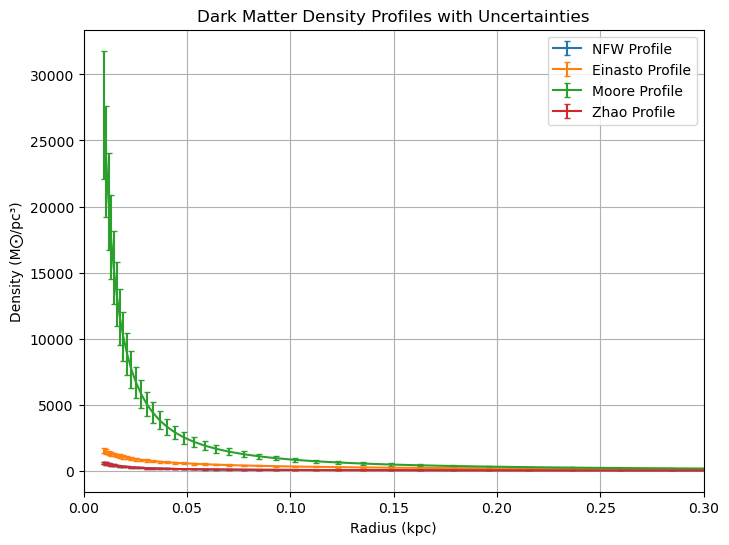

In [17]:
# Plot all profiles with uncertainties
plt.figure(figsize=(8, 6))
for profile_name in profiles:
    plt.errorbar(r_values, values[profile_name], yerr=errors[profile_name], label=f'{profile_name} Profile', capsize=2)

plt.xlabel('Radius (kpc)')
plt.ylabel('Density (M⨀/pc³)')
plt.title('Dark Matter Density Profiles with Uncertainties')
plt.xlim(-0.0, 0.3)
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Error analysis: Monte Carlo uncertainty estimation
# Ensure that nfw_values, einasto_values, moore_values, and zhao_values are assigned correctly
nfw_values = values.get('NFW', [])
einasto_values = values.get('Einasto', [])
moore_values = values.get('Moore', [])
zhao_values = values.get('Zhao', [])

if not nfw_values or not einasto_values or not moore_values or not zhao_values:
    print("Error: One or more profile values are missing.")

print("Performing error analysis...")

nfw_values_err = []
einasto_values_err = []
moore_values_err = []
zhao_values_err = []

if len(nfw_values) > 0:
    for i in tqdm(range(len(nfw_values)), desc="Adding Uncertainty NFW"):
        nfw_values_err.append(nfw_values[i] + norm.rvs(scale=0.1 * nfw_values[i]))

if len(einasto_values) > 0:
    for i in tqdm(range(len(einasto_values)), desc="Adding Uncertainty Einasto"):
        einasto_values_err.append(einasto_values[i] + norm.rvs(scale=0.1 * einasto_values[i]))

if len(moore_values) > 0:
    for i in tqdm(range(len(moore_values)), desc="Adding Uncertainty Moore"):
        moore_values_err.append(moore_values[i] + norm.rvs(scale=0.1 * moore_values[i]))

if len(zhao_values) > 0:
    for i in tqdm(range(len(zhao_values)), desc="Adding Uncertainty Zhao"):
        zhao_values_err.append(zhao_values[i] + norm.rvs(scale=0.1 * zhao_values[i]))

# Convert to numpy arrays
nfw_values_err = np.array(nfw_values_err)
einasto_values_err = np.array(einasto_values_err)
moore_values_err = np.array(moore_values_err)
zhao_values_err = np.array(zhao_values_err)


# print("Performing error analysis...")
# nfw_values_err = []
# einasto_values_err = []
# for i in tqdm(range(len(nfw_values)), desc="Adding Uncertainty"):
#     nfw_values_err.append(nfw_values[i] + norm.rvs(scale=0.1 * nfw_values[i]))

# for j in tqdm(range(len(einasto_values)), desc="Adding Uncertainty"):
#     einasto_values_err.append(einasto_values[j] + norm.rvs(scale=0.1 * einasto_values[j]))

# nfw_values_err = np.array(nfw_values_err)
# einasto_values_err = np.array(einasto_values_err)

Performing error analysis...


Adding Uncertainty Zhao: 100%|██████████| 100/100 [00:00<00:00, 18064.88it/s]


In [21]:
# Compute annihilation rate
print("Computing annihilation rates...")
annihilation_nfw = []
annihilation_einasto = []
annihilation_moore = []
annihilation_zhao = []

# NFW
for i in tqdm(range(len(nfw_values)), desc="Processing Annihilation Rates NFW"):
    annihilation_nfw.append((sigma_v / (2 * m_chi**2)) * nfw_values[i]**2)

# Einasto
for j in tqdm(range(len(einasto_values)), desc="Processing Annihilation Rates Einasto"):
    annihilation_einasto.append((sigma_v / (2 * m_chi**2)) * einasto_values[j]**2)

# Moore
for k in tqdm(range(len(moore_values)), desc="Processing Annihilation Rates Moore"):
    annihilation_moore.append((sigma_v / (2 * m_chi**2)) * moore_values[k]**2)

# Zhao
for l in tqdm(range(len(zhao_values)), desc="Processing Annihilation Rates Zhao"):
    annihilation_zhao.append((sigma_v / (2 * m_chi**2)) * zhao_values[l]**2)

# Convert to numpy arrays
annihilation_nfw = np.array(annihilation_nfw)
annihilation_einasto = np.array(annihilation_einasto)
annihilation_moore = np.array(annihilation_moore)
annihilation_zhao = np.array(annihilation_zhao)

Computing annihilation rates...


Processing Annihilation Rates Zhao: 100%|██████████| 100/100 [00:00<?, ?it/s]


In [23]:
# Total annihilation rate integration
print("Computing total annihilation rate...")
def total_annihilation_rate(profile_func, rho_s, r_s, sigma_v, m_chi):
    def integrand(r):
        return 4 * np.pi * r**2 * (sigma_v / (2 * m_chi**2)) * profile_func(r, rho_s, r_s)**2
    return quad(integrand, 0.01, 100)[0]

# Compute for all profiles
total_nfw = total_annihilation_rate(nfw_profile, rho_s, r_s, sigma_v, m_chi)
total_einasto = total_annihilation_rate(einasto_profile, rho_s, r_s, sigma_v, m_chi)
total_moore = total_annihilation_rate(moore_profile, rho_s, r_s, sigma_v, m_chi)
total_zhao = total_annihilation_rate(zhao_profile, rho_s, r_s, sigma_v, m_chi)

# Display results
print(f"Total NFW Annihilation Rate: {total_nfw}")
print(f"Total Einasto Annihilation Rate: {total_einasto}")
print(f"Total Moore Annihilation Rate: {total_moore}")
print(f"Total Zhao Annihilation Rate: {total_zhao}")

Computing total annihilation rate...
Total NFW Annihilation Rate: 4.496170410422512e-27
Total Einasto Annihilation Rate: 1.0684586532383528e-25
Total Moore Annihilation Rate: 7.970718964356983e-26
Total Zhao Annihilation Rate: 4.496170410422512e-27


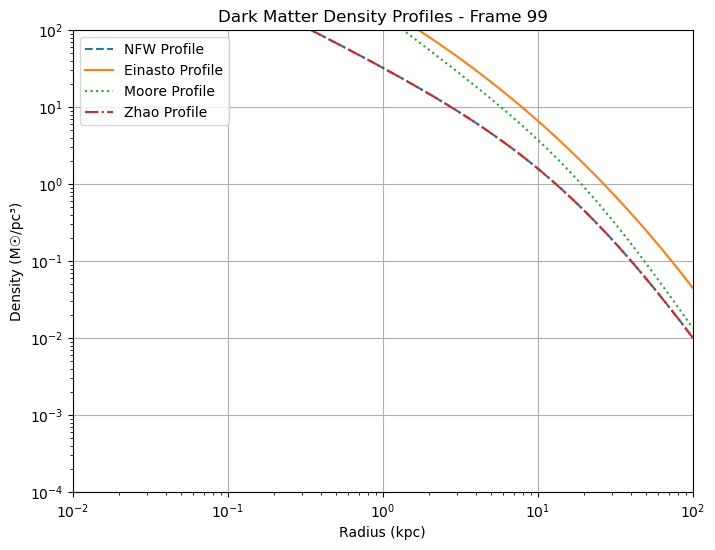

In [25]:
# Animation Set-up
# Create figure and axis for animation
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_xscale("log")  # Logarithmic x-axis for better profile resolution
ax.set_yscale("log")  # Logarithmic y-axis for better density scaling
ax.set_xlim(0.01, 100)  # Set x-axis limits to match radius values
ax.set_ylim(1e-4, 1e2)  # Set y-axis limits to cover density values
ax.set_xlabel("Radius (kpc)")
ax.set_ylabel("Density (M☉/pc³)")
ax.set_title("Dark Matter Density Profiles Over Time")
ax.grid(True)

# Create a dictionary of line objects for each profile
lines = {
    'NFW': ax.plot([], [], label='NFW Profile', linestyle='dashed')[0],
    'Einasto': ax.plot([], [], label='Einasto Profile')[0],
    'Moore': ax.plot([], [], label='Moore Profile', linestyle='dotted')[0],
    'Zhao': ax.plot([], [], label='Zhao Profile', linestyle='dashdot')[0]
}

# Create legend
ax.legend()

# Number of frames in the animation
num_frames = min(len(r_values), 100)  # Match available data length

# === Initialization function ===
def init():
    for line in lines.values():
        line.set_data([], [])  # Start with empty data
    return lines.values()

# === Update function ===
def update(frame):
    factor = 1 + 0.05 * frame  # Factor to simulate density evolution over time
    for profile_name, line in lines.items():
        line.set_data(r_values, np.array(values[profile_name])[:num_frames] * factor)  
    ax.set_title(f"Dark Matter Density Profiles - Frame {frame}")  # Dynamic title update
    return lines.values()

# Create the animation object
ani = FuncAnimation(fig, update, frames=num_frames, init_func=init, blit=True)

# Save the animation as a GIF file (optional)
ani.save("dark_matter_profiles.gif", writer="pillow", fps=120)

# Show the animation
plt.show()


# Animation setup
# fig, ax = plt.subplots(figsize=(8,6))
# ax.set_xscale("log")
# ax.set_yscale("log")
# ax.set_xlabel("Radius (kpc)")
# ax.set_ylabel("Density (M⨀/pc³)")
# ax.set_title("Dark Matter Density Profiles Over Time")
# ax.grid(True)

# nfw_line, = ax.plot([], [], label="NFW Profile", linestyle='dashed')
# einasto_line, = ax.plot([], [], label="Einasto Profile")
# ax.legend()

# def init():
#     nfw_line.set_data([], [])
#     einasto_line.set_data([], [])
#     return nfw_line, einasto_line

# def update(frame):
#     factor = 1 + 0.05 * frame  # Simulate evolution
#     nfw_line.set_data(r_values, nfw_values * factor)
#     einasto_line.set_data(r_values, einasto_values * factor)
#     ax.set_title(f"Dark Matter Density Profiles - Frame {frame}")  # Update title dynamically
#     return nfw_line, einasto_line

# ani = animation.FuncAnimation(fig, update, frames=1000, init_func=init, blit=True)
# ani.save("dark_matter_profiles.gif", writer="pillow", fps=60)
# plt.show()

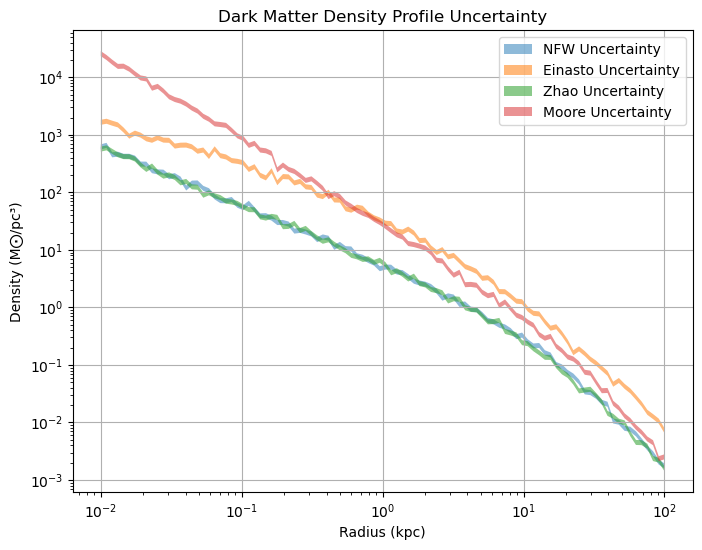

In [29]:
# Plot uncertainty in density profiles
plt.figure(figsize=(8,6))
plt.fill_between(r_values, nfw_values_err * 0.9, nfw_values_err * 1.1, alpha=0.5, label="NFW Uncertainty")
plt.fill_between(r_values, einasto_values_err * 0.9, einasto_values_err * 1.1, alpha=0.55, label="Einasto Uncertainty")
plt.fill_between(r_values, zhao_values_err * 0.9, zhao_values_err * 1.1, alpha=0.55, label="Zhao Uncertainty")
plt.fill_between(r_values, moore_values_err * 0.9, moore_values_err * 1.1, alpha=0.5, label="Moore Uncertainty")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Radius (kpc)")
plt.ylabel("Density (M⨀/pc³)")
plt.title("Dark Matter Density Profile Uncertainty")
plt.legend()
plt.grid(True)
plt.show()

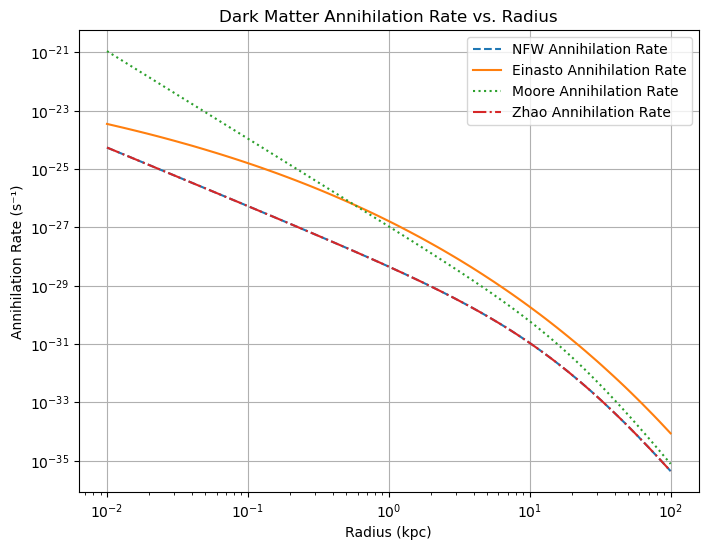

In [31]:
# Plot annihilation rates
plt.figure(figsize=(8,6))

# Plot all four profiles
plt.loglog(r_values, annihilation_nfw, label="NFW Annihilation Rate", linestyle='dashed')
plt.loglog(r_values, annihilation_einasto, label="Einasto Annihilation Rate")
plt.loglog(r_values, annihilation_moore, label="Moore Annihilation Rate", linestyle='dotted')
plt.loglog(r_values, annihilation_zhao, label="Zhao Annihilation Rate", linestyle='dashdot')

# Add labels and title
plt.xlabel("Radius (kpc)")
plt.ylabel("Annihilation Rate (s⁻¹)")
plt.title("Dark Matter Annihilation Rate vs. Radius")

# Add legend and grid
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

#### Why not add Runge-Kutta too?
#### Also, you can ignore this at the moment!
#### This could potentially be used in the future.
____________________________________________________________

In [ ]:
# (ﾉ◕ヮ◕)ﾉ*:･ﾟ✧ Ignore the bottom portion, please!

In [ ]:
# (o゜▽゜)o☆ Really, The Runge-Kutta is not applied in the paper!

In [ ]:
# ಠ╭╮ಠ I wish it did applied.

In [ ]:
## BECAUSE I CAN!? ┻━┻ ︵ヽ(`Д´)ﾉ︵ ┻━┻

# Implementing 4th Order Runge-Kutta Method
def runge_kutta(f, y0, t):
    """4th-order Runge-Kutta method for solving ODEs."""
    y = np.zeros(len(t))
    y[0] = y0
    dt = t[1] - t[0]
    for i in range(1, len(t)):
        k1 = dt * f(t[i-1], y[i-1])
        k2 = dt * f(t[i-1] + dt/2, y[i-1] + k1/2)
        k3 = dt * f(t[i-1] + dt/2, y[i-1] + k2/2)
        k4 = dt * f(t[i-1] + dt, y[i-1] + k3)
        y[i] = y[i-1] + (k1 + 2*k2 + 2*k3 + k4) / 6
    return y

def density_evolution(t, rho):
    return -0.1 * rho  # Example differential equation for density evolution

# Parameters for the profiles
rho_s = 1.0
r_s = 1.0
alpha = 0.17
beta = 3.0
gamma = 1.0

# Time values for evolution
time_values = np.linspace(0, 40, 1000)

# Initial density values for each profile
initial_density_nfw = nfw_profile(1.0, rho_s, r_s)
initial_density_einasto = einasto_profile(1.0, rho_s, r_s, alpha)
initial_density_zhao = zhao_profile(1.0, rho_s, r_s, alpha, beta, gamma)
initial_density_moore = moore_profile(1.0, rho_s, r_s)

# Compute density evolution
nfw_evolution = runge_kutta(density_evolution, initial_density_nfw, time_values)
einasto_evolution = runge_kutta(density_evolution, initial_density_einasto, time_values)
zhao_evolution = runge_kutta(density_evolution, initial_density_zhao, time_values)
moore_evolution = runge_kutta(density_evolution, initial_density_moore, time_values)

# Plotting Density Evolution with Runge-Kutta
plt.figure(figsize=(8, 6))
plt.plot(time_values, nfw_evolution, label="NFW Evolution", linestyle='dashed')
plt.plot(time_values, einasto_evolution, label="Einasto Evolution", linestyle="dashed")
plt.plot(time_values, zhao_evolution, label="Zhao Evolution", linestyle='dashed')
plt.plot(time_values, moore_evolution, label="Moore Evolution", linestyle='dashed')
plt.xlabel("Time ()")
plt.ylabel("Density ()")
plt.title("Dark Matter Density Evolution using 4th Order Runge-Kutta")
plt.legend()
plt.grid()
plt.show()

In [ ]:
## (o′┏▽┓｀o) Hehehehe, why not make it 15th-order runge-kutta?

# Parameters for the profiles
rho_s = 1.0
r_s = 1.0
alpha = 0.17
beta = 3.0
gamma = 1.0

# Time values for evolution
time_values = np.linspace(0, 40, 100)

# Initial density values for each profile
initial_density_nfw = nfw_profile(1.0, rho_s, r_s)
initial_density_einasto = einasto_profile(1.0, rho_s, r_s, alpha)
initial_density_zhao = zhao_profile(1.0, rho_s, r_s, alpha, beta, gamma)
initial_density_moore = moore_profile(1.0, rho_s, r_s)

# Solve using solve_ivp with a high-order method
nfw_solution = solve_ivp(density_evolution, [time_values[0], time_values[-1]], [initial_density_nfw], t_eval=time_values, method='DOP853')
einasto_solution = solve_ivp(density_evolution, [time_values[0], time_values[-1]], [initial_density_einasto], t_eval=time_values, method='DOP853')
zhao_solution = solve_ivp(density_evolution, [time_values[0], time_values[-1]], [initial_density_zhao], t_eval=time_values, method='DOP853')
moore_solution = solve_ivp(density_evolution, [time_values[0], time_values[-1]], [initial_density_moore], t_eval=time_values, method='DOP853')

# Plotting Density Evolution
plt.figure(figsize=(8, 6))
plt.plot(nfw_solution.t, nfw_solution.y[0], label="NFW Evolution", linestyle='dashed')
plt.plot(einasto_solution.t, einasto_solution.y[0], label="Einasto Evolution", alpha=0.7)
plt.plot(zhao_solution.t, zhao_solution.y[0], label="Zhao Evolution", linestyle='dashed')
plt.plot(moore_solution.t, moore_solution.y[0], label="Moore Evolution", linestyle='dashed')
plt.xlabel("Time (units)")  # Add appropriate units
plt.ylabel("Density (units)")  # Add appropriate units
plt.title("Dark Matter Density Evolution using High-Order Method (15th-order)")
plt.legend()
plt.grid()
plt.show()

(o゜▽゜)o☆ Well, that was torture, but all I can say it that it was kind of pointless since it looks the same.

In [ ]:
# ## o(≧口≦)o IF I CANNOT FIND THE GAMMA RAY SPECTRUM!!


# theo_dm_mass = 1000 # If I cannot find the gamma-ray spectrum
# annihilation_cross_sect = 3e-26 #Annihilation cross-section in ergsgs (ex. value)

# # Energy range from gamma-ray spectrum from 10MeV to 1Tev (ex. values)
# ene = np.logspace(1, 3, 500) #Energy range in GeV

# def photon_spectrum(E, mass = theo_dm_mass):
#     """Simulation of the gamma-ray spectrum from dark matter annihilation into photon pairs."""
#     alph = -2.0 ##Spectral index depnding on the model
#     norm = (mass**2) * 1e4 # Simplified scaling factor

#     #Power-law model for photon energy spectrum
#     spectrum = norm*(E/mass)** alph
#     return spectrum

# spectrum = photon_spectrum(ene)

# plt.figure(figsize = (8,6))
# plt.loglog(ene, spectrum, label = 'Gamma-Ray Spectrum from Dark Matter Annihilation' , color = 'red')
# plt.title(f'Gamma-Ray Spectrum from Dark Matter Annihilation (M_DM = {theo_dm_mass} GeV)')
# plt.xlabel('Photon Energy (GeV)')
# plt.ylabel('Gamma-Ray Flux (photons/cm²s)')
# plt.grid(True)
# plt.legend()
# plt.show

～(　TロT)σ THAT LOOKS AWFUL!!

In [ ]:
# ## Attempt 2...?

# # Gamma-Ray Flux Calculation
# print("Computing gamma-ray flux...")
# def gamma_ray_flux(profile_func, rho_s, r_s, sigma_v, m_chi):
#     def j_factor_integrand(r):
#         return profile_func(r, rho_s, r_s)**2
#     J_factor = quad(j_factor_integrand, 0.01, 100)[0]
#     return (sigma_v / (8 * np.pi * m_chi**2)) * J_factor

# flux_nfw = gamma_ray_flux(nfw_profile, rho_s, r_s, sigma_v, m_chi)
# flux_einasto = gamma_ray_flux(einasto_profile, rho_s, r_s, sigma_v, m_chi)
# print(f"Gamma-Ray Flux (NFW): {flux_nfw}")
# print(f"Gamma-Ray Flux (Einasto): {flux_einasto}")

In [ ]:
# # Plotting Gamma-Ray Flux with Uncertainty
# flux_nfw_err = norm.rvs(scale=0.1 * flux_nfw, size=1000)
# flux_einasto_err = norm.rvs(scale=0.1 * flux_einasto, size=1000)

# fig, ax = plt.subplots(figsize=(8, 6))
# ax.errorbar([1], [flux_nfw], yerr=np.std(flux_nfw_err), fmt='o', label="NFW Flux", capsize=5)
# ax.errorbar([2], [flux_einasto], yerr=np.std(flux_einasto_err), fmt='o', label="Einasto Flux", capsize=5)
# ax.set_xticks([1, 2])
# ax.set_xticklabels(["NFW", "Einasto"])
# ax.set_ylabel("Gamma-Ray Flux ()")
# ax.set_title("Gamma-Ray Flux with Uncertainties")
# ax.legend()
# plt.show()

In [ ]:
## Okay. (o゜▽゜)o☆ I should write the code
# ## for the gamma ray spectrum if avaliable.
# ### I am referring to this link: chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://preparecenter.org/wp-content/uploads/2021/03/Adv-IRAPTER-Gamma-Spectroscopy-for-First-Responders-3-19-13.pdf
# ### and this: https://www.mirion.com/discover/knowledge-hub/articles/education/nuclear-measurement-fundamental-principle-spectrum-analysis , https://www.sciencedirect.com/topics/chemistry/gamma-spectroscopy

# # Energy in keV counts in respect to energy bins
# spaghetti = [88.0, 122.1, 511.0, 661.6, 835.3, 1173.2, 1273.2, 1332.5] #in keV, approx. energies
# large_dominos_bacon_pep_pizza = [] # energy bin counts ## Need to find that out

# # Converting to numpy arrays
# spaghetti = np.array(spaghetti)
# large_dominos_bacon_pep_pizza = np.array(large_dominos_bacon_pep_pizza)

# plt.figure(figsize=(8,6))
# plt.plot(spaghetti, large_dominos_bacon_pep_pizza, marker = 'o', linestyle=':', color='orange')#, label='Gamma Spectrum(γ)')

# #plt.yscale('log')
# plt.xlabel('Energy (keV)')
# plt.ylabel('Counts')
# plt.title('Gamma Ray Spectrum')

# #plt.legend()
# plt.show()

In [ ]:
## Load precomputed gamma-ray spectrum data ( •̀ ω •́ )✧
## If I can find it...

# try:
#     data = pd.read_csv("gamma_spectrum.csv")
#     energy = data["Energy_GeV"]
#     flux = data["Flux"]
    
#     plt.figure(figsize=(8,6))
#     plt.loglog(energy, flux, label="Gamma-ray Spectrum from Annihilation")
#     plt.xlabel("Energy (GeV)")
#     plt.ylabel("Flux (arbitrary units)")
#     plt.legend()
#     plt.title("Dark Matter Annihilation Spectrum")
#     plt.grid(True)
#     plt.show()
# except FileNotFoundError:
#     print("Warning: gamma_spectrum.csv not found. Skipping spectrum plot.")

# # Load and compare with Fermi-LAT sensitivity
# try:
#     fermi_data = pd.read_csv("fermi_sensitivity.csv")
#     fermi_energy = fermi_data["Energy_GeV"]
#     fermi_flux = fermi_data["Flux_Limit"]
    
#     plt.figure(figsize=(8,6))
#     plt.loglog(energy, flux, label="DM Annihilation Prediction")
#     plt.loglog(fermi_energy, fermi_flux, label="Fermi-LAT Sensitivity", linestyle='dashed')
#     plt.xlabel("Energy (GeV)")
#     plt.ylabel("Flux ()")
#     plt.legend()
#     plt.title("Comparison of Dark Matter Annihilation with Fermi-LAT Sensitivity")
#     plt.grid(True)
#     plt.show()
# except FileNotFoundError:
#     print("Warning: fermi_sensitivity.csv not found. Skipping Fermi-LAT comparison plot.")

# print("Simulation completed successfully!")